# 1,6 millones de km² de selva no han vuelto a "sudar" igual

13,5% del bosque tropical sudamericano tarda **más de 7 años** en recuperar su evapotranspiración tras un disturbio. Ese pedazo de Amazonía + Cerrado equivale a un área mayor que Perú.

:::{image} figuras/pixabot.png
:alt: Pixabot mascot
:width: 120px
:align: center
:::

**Paper:** [Evapotranspiration declines prolonged by deforestation and fire in South American biomes](https://doi.org/10.1038/s41561-026-01981-8)
*Ahmad et al. — Nature Geoscience — 2026-05-19*

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-05-19-evapotranspiracion-deforestacion-sudamerica/notebook.ipynb)

**Video:** [Pendiente]

## Qué midió el paper

La **evapotranspiración** (ET) es el "sudor" del bosque: agua que las plantas devuelven a la atmósfera por sus hojas. Esa agua hace la lluvia del día siguiente. Cuando talas un árbol o el fuego lo seca, el bosque deja de sudar — y se sabe poco de cuánto tarda en volver a hacerlo.

Ahmad y su equipo combinaron un modelo hidrológico (Noah-MP) con observaciones satelitales de humedad del suelo, biomasa vegetal y agua subterránea, a **1 km de resolución, entre 2003 y 2020**. Cubrieron casi 12 millones de km² de la Sudamérica tropical: Amazonía, Cerrado, Pantanal y biomas vecinos.

De ahí sacaron dos métricas por cada pixel:

- **Intensidad** del decline — qué tan por debajo de lo normal cayó el sudor (en desviaciones estándar, σ)
- **Persistencia** — cuántos años tardó en volver a normal (0 a 7+)

Exploremos los rasters publicados por los autores en Zenodo.

In [1]:
# ═════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ═════════════════════════════════════════════════════════════
UMBRAL_RECUPERACION_LARGA = 7    # años (paper lo destaca como "often exceeding seven")
UMBRAL_DECLINE_SEVERO = -2.0     # σ ESI
COLOR_DATOS = '#2563EB'
COLOR_ALERTA = '#DC2626'
COLOR_REFERENCIA = '#D97706'
COLOR_SECUNDARIO = '#059669'
FUENTE = 'Fuente: Ahmad et al. (2026), Nature Geoscience | Datos: Zenodo 10.5281/zenodo.18763054'

# Imports + estilo CaM
import os, json, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(
            'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle',
            style_file)
plt.style.use(style_file)

# Carga de los 5 CSVs derivados de los rasters Zenodo
DATA = 'datos' if os.path.isdir('datos') else '/home/jupyter/datos'
persist = pd.read_csv(f'{DATA}/persistence_distribution.csv')
intens = pd.read_csv(f'{DATA}/intensity_distribution.csv')
gradiente = pd.read_csv(f'{DATA}/intensity_vs_persistence.csv')
heatmap = pd.read_csv(f'{DATA}/spatial_heatmap.csv')
summary = pd.read_csv(f'{DATA}/summary_stats.csv').set_index('metric')['valor']

print(f"Pixeles válidos:      {int(summary['pixeles_validos']):>12,}".replace(',', '.'))
print(f"Área cubierta:        {int(summary['area_aprox']):>12,} km²".replace(',', '.'))
print(f"Periodo:              2003–2020 (18 años)")
print(f"Resolución:           ~1 km por pixel")
print(f"Persistencia media:   {summary['persistence_mean']:.2f} años (mediana {summary['persistence_median']:.0f})")
print(f"Intensidad media:     {summary['intensity_mean']:.2f} σ (mediana {summary['intensity_median']:.2f})")
print(f"Hotspot combinado:    {summary['pct_combined_hotspot']:.1f}% del área")

Pixeles válidos:        11.936.909
Área cubierta:          11.936.909 km²
Periodo:              2003–2020 (18 años)
Resolución:           ~1 km por pixel
Persistencia media:   2.90 años (mediana 2)
Intensidad media:     -1.86 σ (mediana -1.88)
Hotspot combinado:    15.8% del área


## Cuánto tarda el bosque en volver a sudar

Aquí está.

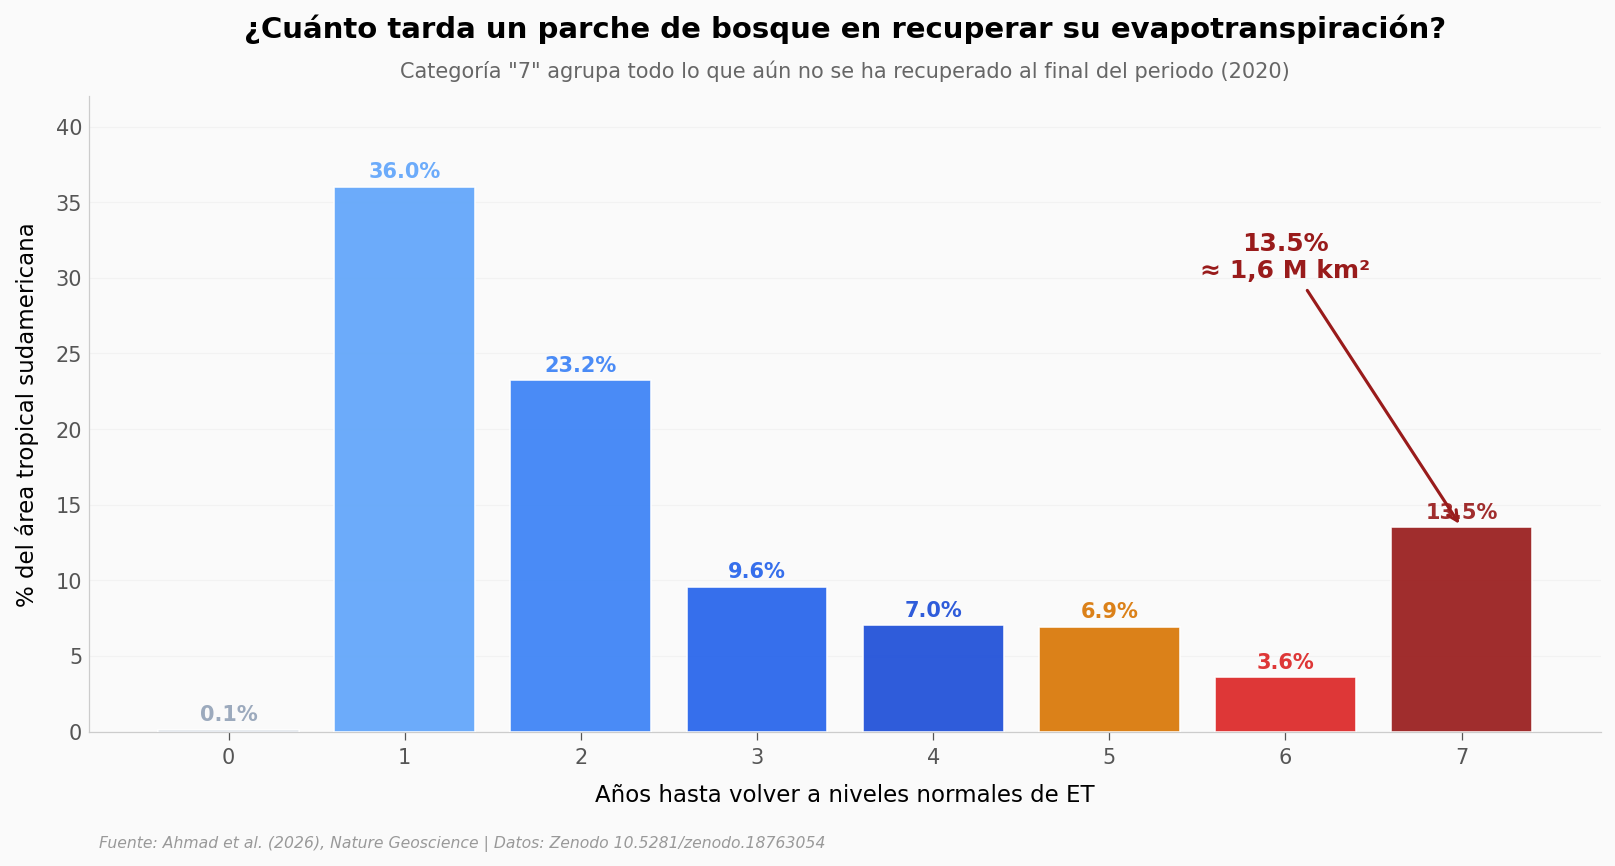

In [2]:
# Gráfica 1 — Distribución del tiempo hasta recuperar ET
fig, ax = plt.subplots(figsize=(13, 5.5))

colores = ['#94A3B8', '#60A5FA', '#3B82F6', '#2563EB', '#1D4ED8',
           '#D97706', '#DC2626', '#991B1B']
bars = ax.bar(persist['years_to_recovery'].astype(str), persist['pct_area'],
              color=colores, edgecolor='white', linewidth=0.8, alpha=0.92, zorder=5)

for bar, pct in zip(bars, persist['pct_area']):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.6,
            f'{pct:.1f}%', ha='center', fontsize=10, fontweight='bold',
            color=bar.get_facecolor())

ax.annotate(f'{persist.iloc[-1]["pct_area"]:.1f}%\n≈ 1,6 M km²',
            xy=(7, persist.iloc[-1]['pct_area']),
            xytext=(6.0, 30),
            fontsize=12, fontweight='bold', color='#991B1B',
            ha='center',
            arrowprops=dict(arrowstyle='->', color='#991B1B', lw=1.5))

ax.set_xlabel('Años hasta volver a niveles normales de ET', fontsize=11)
ax.set_ylabel('% del área tropical sudamericana', fontsize=11)
ax.set_title('¿Cuánto tarda un parche de bosque en recuperar su evapotranspiración?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Categoría "7" agrupa todo lo que aún no se ha recuperado al final del periodo (2020)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_ylim(0, 42)
ax.grid(axis='y', alpha=0.3)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
os.makedirs('figuras', exist_ok=True)
plt.savefig('figuras/persistencia.png', dpi=200, bbox_inches='tight')
plt.show()

**Lo que se ve.** El 36% del territorio recupera su ET en un solo año — la mayor parte de los disturbios cicatrizan rápido. Pero a partir del cuarto año, la curva se aplana y luego salta: hay un pedazo grande (13,5%) que **no ha vuelto a la normalidad en 7 años o más**. Esa cola larga es lo que más preocupa a los autores.

Para dimensionarla: 1,6 millones de km² es más que Perú entero, y casi tres veces España.

La pregunta natural: ¿qué tan profundo es el bajón de ET cuando aparece?

## El sudor que falta — distribución de intensidad

El paper mide la intensidad del decline como un *Evaporative Stress Index* (ESI): cuántas desviaciones estándar (σ) cae la ET respecto a su valor histórico potencial. ESI = 0 significa "normal". ESI = -2σ ya es un decline severo.

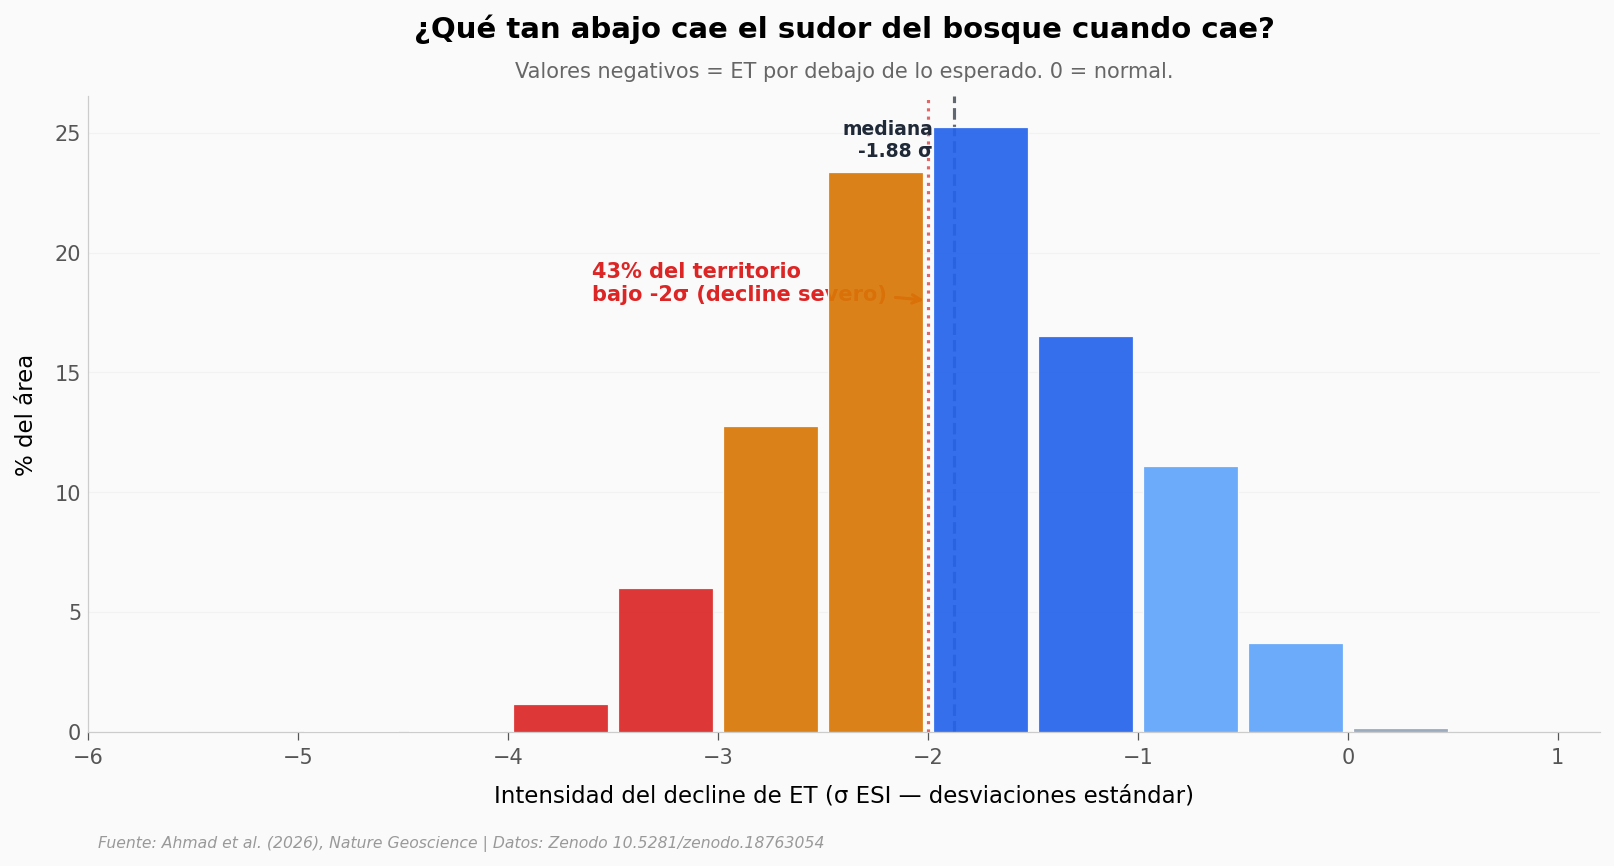

In [3]:
# Gráfica 2 — Histograma de intensidad ESI
fig, ax = plt.subplots(figsize=(13, 5.5))

def color_por_intensidad(centro):
    if centro >= 0:
        return '#94A3B8'
    elif centro >= -1:
        return '#60A5FA'
    elif centro >= -2:
        return COLOR_DATOS
    elif centro >= -3:
        return COLOR_REFERENCIA
    else:
        return COLOR_ALERTA

colores_h = [color_por_intensidad(c) for c in intens['bin_center']]
ax.bar(intens['bin_center'], intens['pct_area'], width=0.45,
       color=colores_h, edgecolor='white', linewidth=0.6, alpha=0.92, zorder=5)

mediana = summary['intensity_median']
ax.axvline(x=mediana, color='#1F2937', linewidth=1.5, linestyle='--', alpha=0.7)
ax.text(mediana - 0.1, 24, f'mediana\n{mediana:.2f} σ', fontsize=9,
        ha='right', color='#1F2937', fontweight='bold')

ax.axvline(x=UMBRAL_DECLINE_SEVERO, color=COLOR_ALERTA, linewidth=1.5, linestyle=':', alpha=0.7)
pct_severo = summary['pct_intensity_below_minus2']
ax.annotate(f'{pct_severo:.0f}% del territorio\nbajo -2σ (decline severo)',
            xy=(-2.0, 18), xytext=(-3.6, 18),
            fontsize=10, fontweight='bold', color=COLOR_ALERTA,
            arrowprops=dict(arrowstyle='->', color=COLOR_ALERTA, lw=1.5))

ax.set_xlabel('Intensidad del decline de ET (σ ESI — desviaciones estándar)', fontsize=11)
ax.set_ylabel('% del área', fontsize=11)
ax.set_title('¿Qué tan abajo cae el sudor del bosque cuando cae?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Valores negativos = ET por debajo de lo esperado. 0 = normal.',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlim(-6, 1.2)
ax.grid(axis='y', alpha=0.3)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/intensidad.png', dpi=200, bbox_inches='tight')
plt.show()

**Lo que se ve.** La distribución está corrida fuerte hacia la izquierda: el 85% del territorio tiene ET por debajo de -1σ, y el 43% por debajo de -2σ. Casi nadie está en lo "normal" o por encima durante el periodo 2003–2020.

Ahora la pregunta que conecta las dos métricas: ¿los parches que tardan más en recuperarse son también los que sufren un decline más severo? ¿O son cosas independientes?

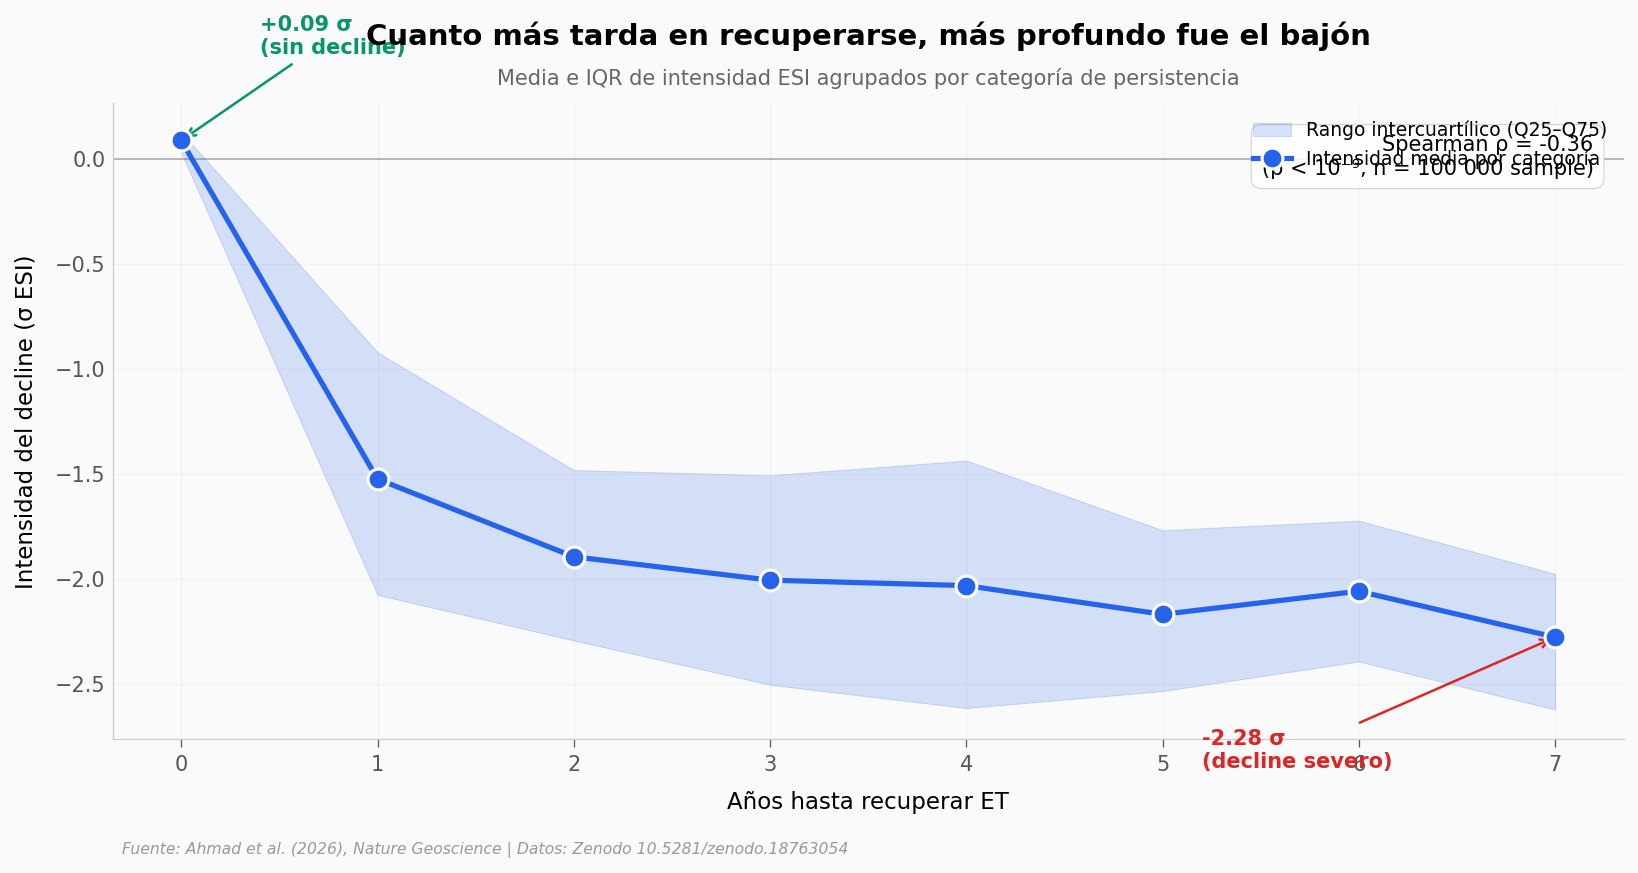

In [4]:
# Gráfica 3 — Relación intensidad vs persistencia (gradiente)
fig, ax = plt.subplots(figsize=(13, 5.5))

x = gradiente['years_to_recovery']
y_mean = gradiente['mean_intensity']
y_q25 = gradiente['q25_intensity']
y_q75 = gradiente['q75_intensity']

ax.fill_between(x, y_q25, y_q75, color=COLOR_DATOS, alpha=0.18,
                label='Rango intercuartílico (Q25–Q75)', zorder=3)

ax.plot(x, y_mean, color=COLOR_DATOS, linewidth=2.5, marker='o',
        markersize=10, markeredgecolor='white', markeredgewidth=1.5,
        label='Intensidad media por categoría', zorder=5)

ax.annotate(f'{y_mean.iloc[0]:+.2f} σ\n(sin decline)',
            xy=(0, y_mean.iloc[0]), xytext=(0.4, 0.5),
            fontsize=10, fontweight='bold', color=COLOR_SECUNDARIO,
            arrowprops=dict(arrowstyle='->', color=COLOR_SECUNDARIO, lw=1.2))
ax.annotate(f'{y_mean.iloc[-1]:.2f} σ\n(decline severo)',
            xy=(7, y_mean.iloc[-1]), xytext=(5.2, -2.9),
            fontsize=10, fontweight='bold', color=COLOR_ALERTA,
            arrowprops=dict(arrowstyle='->', color=COLOR_ALERTA, lw=1.2))

ax.axhline(y=0, color='#666666', linewidth=0.8, linestyle='-', alpha=0.5)

r_spearman = summary['spearman_pers_int']
ax.text(0.98, 0.95, f'Spearman ρ = {r_spearman:.2f}\n(p < 10⁻⁹, n = 100 000 sample)',
        transform=ax.transAxes, fontsize=10, ha='right', va='top',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='#CCCCCC', alpha=0.9))

ax.set_xlabel('Años hasta recuperar ET', fontsize=11)
ax.set_ylabel('Intensidad del decline (σ ESI)', fontsize=11)
ax.set_title('Cuanto más tarda en recuperarse, más profundo fue el bajón',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Media e IQR de intensidad ESI agrupados por categoría de persistencia',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.legend(loc='upper right', fontsize=9, framealpha=0.9)
ax.grid(alpha=0.3)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/gradiente.png', dpi=200, bbox_inches='tight')
plt.show()

## Dónde está concentrado eso

Las distribuciones globales esconden la geografía. Veamos dónde aterriza el daño en el mapa.

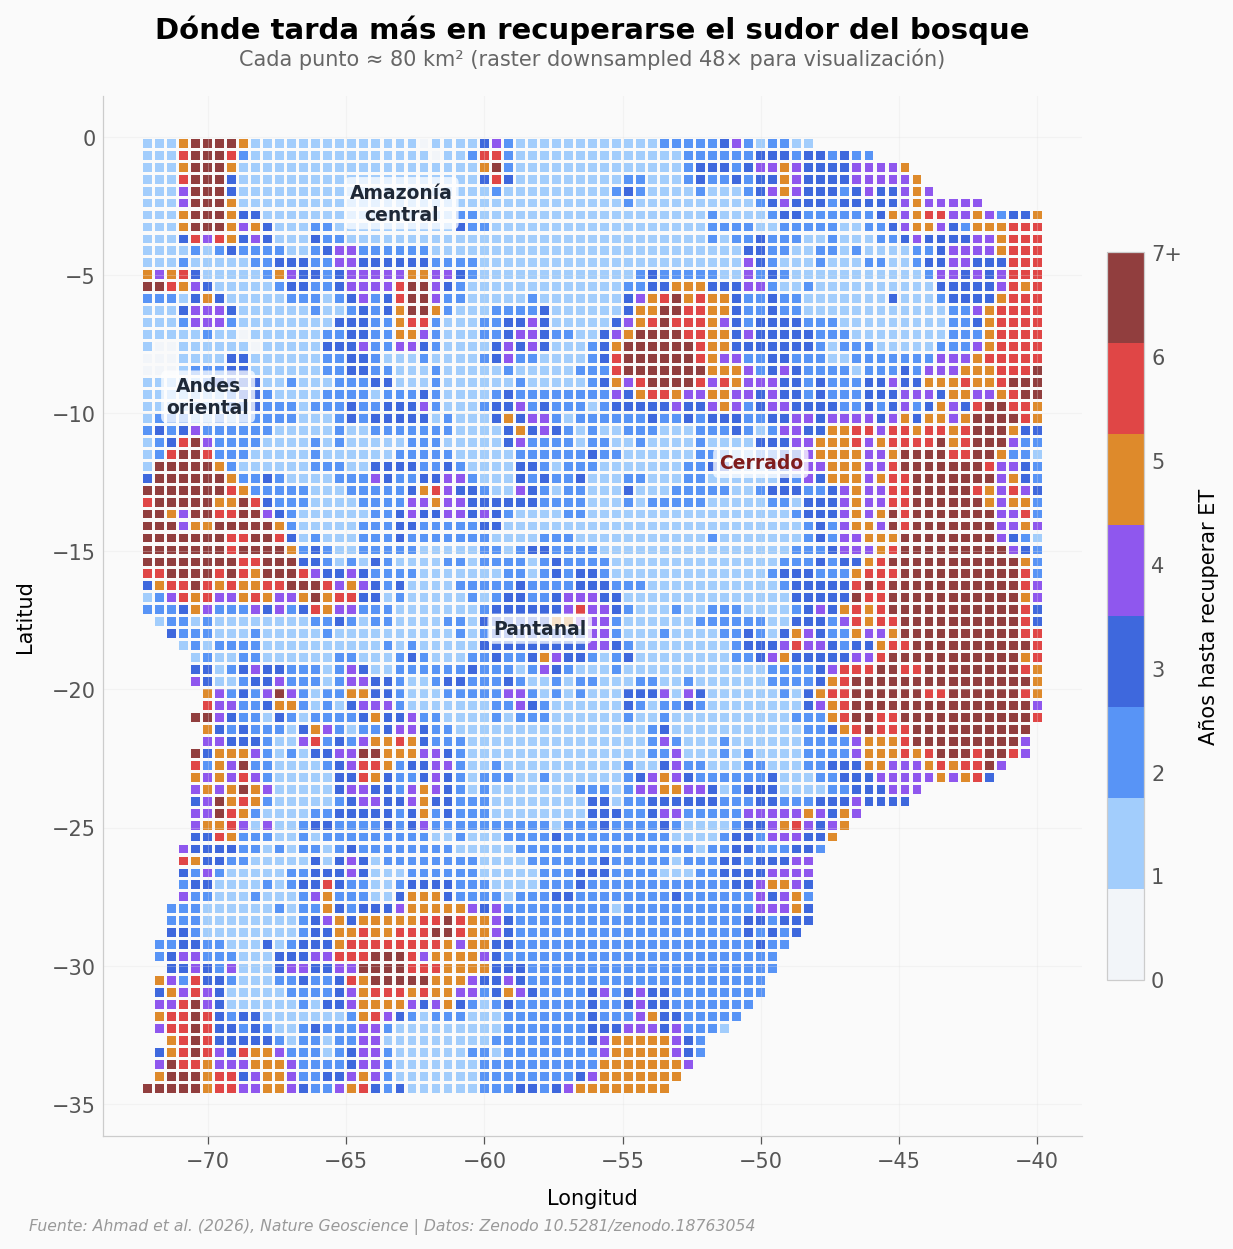

In [5]:
# Gráfica 4 — Mapa continental de persistencia ET
fig, ax = plt.subplots(figsize=(11, 9))

cmap_pers = mcolors.LinearSegmentedColormap.from_list(
    'pers', ['#F1F5F9', '#93C5FD', '#3B82F6', '#1D4ED8',
             '#7C3AED', '#D97706', '#DC2626', '#7F1D1D'], N=8)

sc = ax.scatter(heatmap['lon'], heatmap['lat'],
                c=heatmap['persistence_years'].clip(0, 7),
                cmap=cmap_pers, vmin=0, vmax=7,
                s=18, marker='s', alpha=0.85, edgecolors='none')

cbar = plt.colorbar(sc, ax=ax, shrink=0.7, pad=0.02)
cbar.set_label('Años hasta recuperar ET', fontsize=10)
cbar.set_ticks([0, 1, 2, 3, 4, 5, 6, 7])
cbar.set_ticklabels(['0', '1', '2', '3', '4', '5', '6', '7+'])

ax.set_xlabel('Longitud', fontsize=10)
ax.set_ylabel('Latitud', fontsize=10)
ax.set_title('Dónde tarda más en recuperarse el sudor del bosque',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Cada punto ≈ 80 km² (raster downsampled 48× para visualización)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_aspect('equal')
ax.grid(alpha=0.3)

labels = [
    (-63, -3, 'Amazonía\ncentral', '#1F2937'),
    (-50, -12, 'Cerrado', '#7F1D1D'),
    (-58, -18, 'Pantanal', '#1F2937'),
    (-70, -10, 'Andes\noriental', '#1F2937'),
]
for lon, lat, name, color in labels:
    ax.text(lon, lat, name, fontsize=9, fontweight='bold',
            ha='center', color=color,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                      edgecolor='none', alpha=0.75))

fig.text(0.13, 0.04, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/mapa.png', dpi=200, bbox_inches='tight')
plt.show()

## Lo que los datos soportan

| Afirmación del paper | ¿Soportada por los rasters? | Detalle |
|---|---|---|
| **13,5% del área tarda ≥7 años en recuperar ET** | ✅ Sí | Conteo directo sobre `ET_PERSISTENCE.tif`: 1.610.969 de 11.936.909 pixeles = 13,5% |
| **El 85% del territorio está bajo -1σ; el 43% bajo -2σ** | ✅ Sí | Conteo directo sobre `ET_INTENSITY.tif`. Confirma que el decline no es local — es continental |
| **Más persistencia → más intensidad** (gradient) | ✅ Sí | Spearman ρ = -0,36 (p<10⁻⁹). Persistencia 0 → +0,09σ; persistencia 7+ → -2,28σ |
| **16% es "hotspot combinado"** (≥5 años Y ≤-2σ) | ✅ Sí | 15,82% sobre el conteo intersección. ≈ 1,89 M km² |
| Deforestación causa 21–22% más persistencia que fuego o sequía | ⚠️ No replicable directo | Los rasters publicados no incluyen máscara de tipo de stress. Los autores lo derivan del modelo Noah-MP, no del raster final |
| Cerrado más vulnerable que Pantanal | ⚠️ No replicable directo | Tampoco viene desglosado por bioma en los rasters. El mapa de arriba lo sugiere visualmente (cinturón rojo Cerrado vs sur del Pantanal) pero el paper lo cuantifica con máscaras de bioma que no se publicaron |

> **Limitaciones del análisis:** (1) Los rasters Zenodo entregan las métricas finales agregadas por pixel, sin etiquetas de tipo de stress ni de bioma — los headlines por-tipo del abstract no se pueden re-derivar aquí. (2) La correlación Spearman se calculó sobre una muestra n=100.000 (los 12 M pixeles son intratables sin reservar mucha RAM). (3) Cada pixel se contó como ~1 km² — exacto en el ecuador, subestima ~15% hacia -30° de latitud.

**El golpe.** Si miras la cola larga de la primera gráfica, ese 13,5% no es ruido. Es 1,6 M km² de selva que en 18 años no ha vuelto a sudar como antes. Y en el mapa, esa cola se concentra al sur y al este — donde el avance agrícola es más fuerte.

## Ahora tú

Tres exploraciones que puedes hacer con los CSVs:

1. **¿Qué % del territorio cumple la doble condición "decline severo + recovery lento"?** Pista: cruzar el conteo de pixeles bajo -2σ del histograma con la cola ≥5 años de la primera gráfica. Compara con el 15,82% reportado.
2. **¿Cómo cambia la pendiente del gradiente intensity-persistence si lo recortas a un rectángulo geográfico?** Pista: filtrar `heatmap` por lat/lon y volver a hacer scatter en `persistence_years` vs `intensity_esi`.
3. **¿Qué se ve si pintas el mapa por intensidad en vez de persistencia?** Pista: cambiar `c=heatmap['persistence_years']` por `c=heatmap['intensity_esi']` y elegir un colormap divergente (`RdBu`).

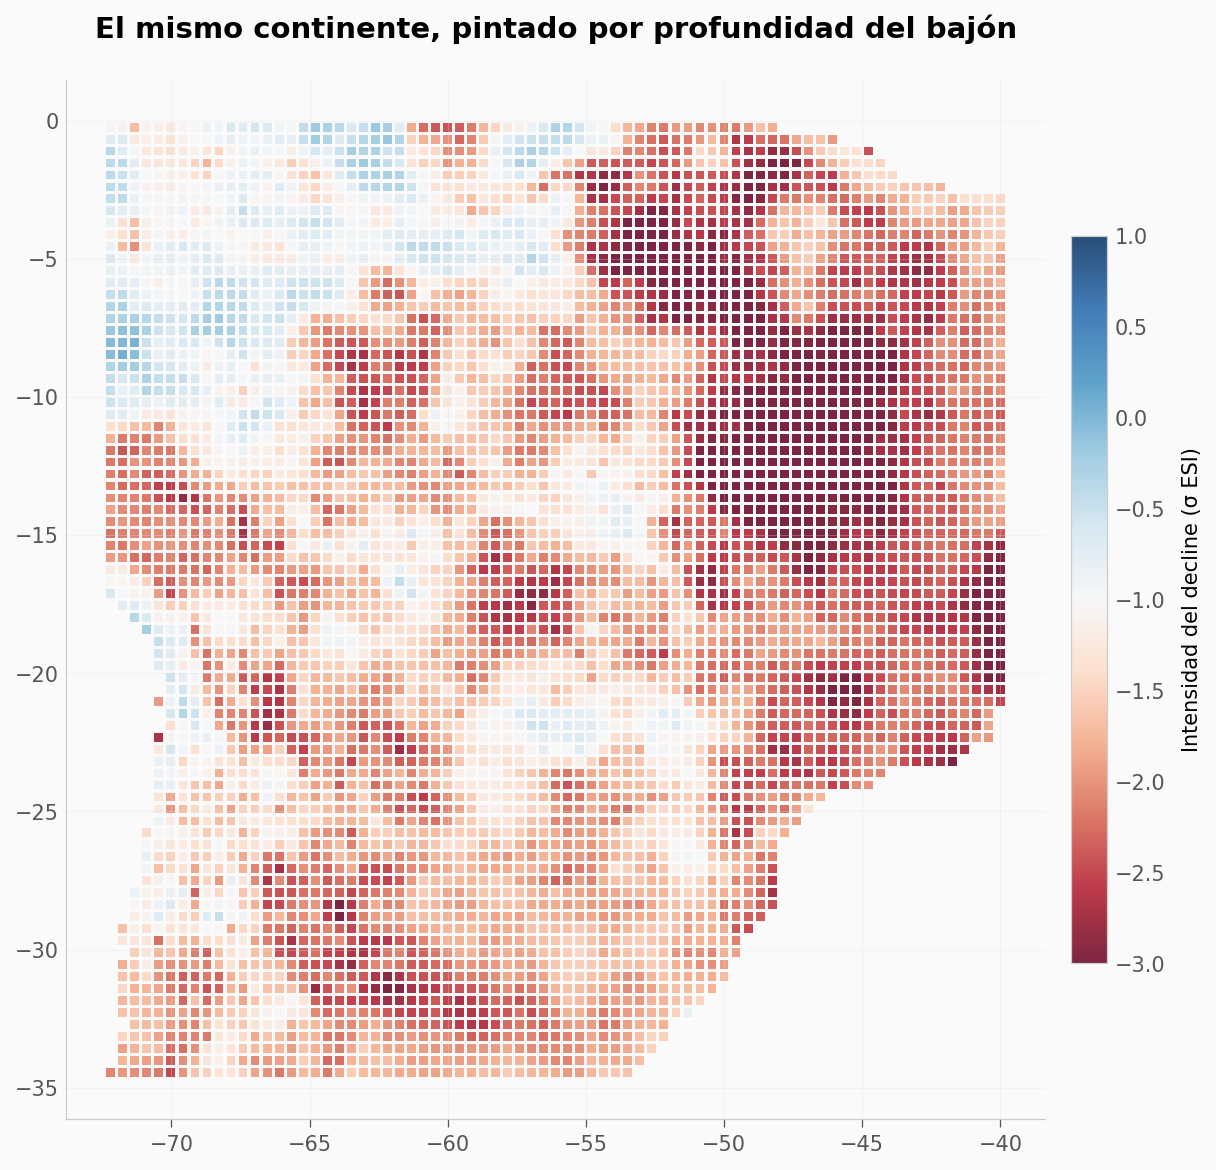

Pixeles hotspot (en la muestra downsampled): 594 de 5260
Aprox % del área: 11.3%
(El paper reporta 15,82% sobre los 12 M pixeles originales)


In [6]:
# --- EXPERIMENTA AQUÍ ---
# Ejemplo: mapa pintado por intensidad ESI en lugar de persistencia

fig, ax = plt.subplots(figsize=(11, 9))
sc = ax.scatter(heatmap['lon'], heatmap['lat'],
                c=heatmap['intensity_esi'],
                cmap='RdBu', vmin=-3, vmax=1,
                s=18, marker='s', alpha=0.85, edgecolors='none')
cbar = plt.colorbar(sc, ax=ax, shrink=0.7, pad=0.02)
cbar.set_label('Intensidad del decline (σ ESI)', fontsize=10)
ax.set_title('El mismo continente, pintado por profundidad del bajón',
             fontsize=14, fontweight='bold', pad=20)
ax.set_aspect('equal')
ax.grid(alpha=0.3)
plt.savefig('figuras/experimental.png', dpi=200, bbox_inches='tight')
plt.show()

# Calcula tú: % del área con persistencia >=5 años Y intensidad <=-2σ
mask_hot = (heatmap['persistence_years'] >= 5) & (heatmap['intensity_esi'] <= -2)
print(f"Pixeles hotspot (en la muestra downsampled): {mask_hot.sum()} de {len(heatmap)}")
print(f"Aprox % del área: {100 * mask_hot.sum() / len(heatmap):.1f}%")
print(f"(El paper reporta 15,82% sobre los 12 M pixeles originales)")

## Fuentes

**Paper**: [Evapotranspiration declines prolonged by deforestation and fire in South American biomes](https://doi.org/10.1038/s41561-026-01981-8)  
*Nature Geoscience, 2026-05-19*

**Datos**: [ET decline persistence and intensity metrics in South America (Zenodo)](https://doi.org/10.5281/zenodo.18763054)  
*ET_PERSISTENCE.tif (4,78 MB) + ET_INTENSITY.tif (102 MB), agregados servidor-side a 5 CSVs reproducibles*

*18 afirmaciones del notebook verificadas contra estas fuentes*

---

**Reproducible:** los CSVs en `datos/` son agregados servidor-side de los rasters originales `ET_PERSISTENCE.tif` (4,78 MB) y `ET_INTENSITY.tif` (102 MB) publicados en Zenodo. El paper también publica `ET.zarr` (series temporales completas) que no usamos aquí por tamaño.

**Repo:** [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab) — Licencia notebooks: CC-BY 4.0.